# Количественное исследование текстового корпуса

Датасет был найден на kaggle (https://www.kaggle.com/datasets/d0rj3228/russian-literature?select=README.md), скачан из репозитория на GitHub (https://github.com/d0rj/RusLit/tree/main). При загрузке с kaggle слетает кодировка в названиях txt файлов.

In [174]:
import os
from pathlib import Path
import pandas as pd
import re
from nltk.corpus import stopwords
from collections import Counter
from collections import defaultdict
import nltk
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
import pymorphy3
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import scipy.cluster.hierarchy as sch
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor

# Загрузка и подготовка данных

Создаем корпуса для каждого автора отдельно по жанру, то есть один и тот же автора получает отдельные корпуса для поэзии, для прозы и для публицистики.

utf-8 не подошла, поэтому сразу пробуем все кодировки.

In [44]:
base_path = Path("RusLit-main")
corpora = {}

encodings = ['utf-8', 'cp1251', 'koi8-r', 'iso-8859-5']

for genre_dir in base_path.iterdir():
    if not genre_dir.is_dir():
        continue
    
    genre = genre_dir.name
    
    for author_dir in genre_dir.iterdir():
        if not author_dir.is_dir():
            continue
        
        author = author_dir.name
        corpus_name = f"{author}_{genre}"
        
        texts = []
        for file in author_dir.glob("*.txt"):
            for enc in encodings:
                try:
                    with open(file, 'r', encoding=enc) as f:
                        texts.append(f.read())
                    break
                except UnicodeDecodeError:
                    continue
        
        full_text = ' '.join(texts)
        
        years = []
        info_file = author_dir / "info.csv"
        if info_file.exists():
            try:
                df_info = pd.read_csv(info_file)
                if 'year' in df_info.columns:
                    for year_str in df_info['year'].dropna():
                        if '-' in str(year_str):
                            parts = str(year_str).split('-')
                            for part in parts:
                                try:
                                    years.append(int(part.strip()))
                                except:
                                    pass
                        else:
                            try:
                                years.append(int(year_str))
                            except:
                                pass
            except:
                pass
        
        if years:
            year_start = min(years)
            year_end = max(years)
            year_range = f"{year_start}-{year_end}"
        else:
            year_start = None
            year_end = None
            year_range = None
        
        corpora[corpus_name] = {
            'author': author,
            'genre': genre,
            'text': full_text,
            'file_count': len(texts),
            'year_start': year_start,
            'year_end': year_end,
            'year_range': year_range
        }

print(f"Создано корпусов: {len(corpora)}")
for name, data in corpora.items():
    print(f"{name}: {data['file_count']} файлов, {len(data['text'])} символов, годы: {data['year_range']}")

Создано корпусов: 16
Blok_poems: 10 файлов, 911319 символов, годы: 1915-1921
Lermontov_poems: 18 файлов, 41036 символов, годы: None
Nekrasov_poems: 15 файлов, 351257 символов, годы: None
Pushkin_poems: 35 файлов, 540943 символов, годы: 1816-1836
Blok_prose: 4 файлов, 40679 символов, годы: 1906-1921
Bryusov_prose: 30 файлов, 2830896 символов, годы: 1894-1934
Chekhov_prose: 77 файлов, 1834329 символов, годы: 1881-1904
Dostoevsky_prose: 33 файлов, 11221678 символов, годы: 1846-1881
Gogol_prose: 16 файлов, 2289720 символов, годы: 1831-1842
Gorky_prose: 33 файлов, 4324024 символов, годы: 1892-1923
Herzen_prose: 11 файлов, 1282315 символов, годы: 1836-1869
Lermontov_prose: 3 файлов, 323344 символов, годы: 1840-1846
Pushkin_prose: 10 файлов, 932231 символов, годы: 1827-1836
Tolstoy_prose: 42 файлов, 9392434 символов, годы: 1852-1910
Turgenev_prose: 10 файлов, 2345242 символов, годы: 1852-1882
Tolstoy_publicism: 26 файлов, 662650 символов, годы: 1882-1910


Посмотрим сразу на среднюю длину предложений у авторов.

In [45]:
for name, data in corpora.items():
    text = data['text']
    
    sentences = re.split(r'[.!?]+', text)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 0]
    
    sentence_lengths = [len(s.split()) for s in sentences]
    
    avg_length = sum(sentence_lengths) / len(sentence_lengths) if sentence_lengths else 0
    
    print(f"{name}: {avg_length:.2f} слов в предложении")

Blok_poems: 10.66 слов в предложении
Lermontov_poems: 13.34 слов в предложении
Nekrasov_poems: 9.04 слов в предложении
Pushkin_poems: 12.16 слов в предложении
Blok_prose: 14.09 слов в предложении
Bryusov_prose: 16.52 слов в предложении
Chekhov_prose: 9.65 слов в предложении
Dostoevsky_prose: 14.14 слов в предложении
Gogol_prose: 13.24 слов в предложении
Gorky_prose: 11.03 слов в предложении
Herzen_prose: 17.47 слов в предложении
Lermontov_prose: 12.69 слов в предложении
Pushkin_prose: 12.49 слов в предложении
Tolstoy_prose: 13.44 слов в предложении
Turgenev_prose: 13.18 слов в предложении
Tolstoy_publicism: 23.22 слов в предложении


Посмотрим на среднюю длину предложений по жанрам.

In [46]:
genre_stats = {}

for name, data in corpora.items():
    genre = data['genre']
    text = data['text']
    
    sentences = re.split(r'[.!?]+', text)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 0]
    sentence_lengths = [len(s.split()) for s in sentences]
    avg_length = sum(sentence_lengths) / len(sentence_lengths) if sentence_lengths else 0
    
    if genre not in genre_stats:
        genre_stats[genre] = []
    genre_stats[genre].append(avg_length)

for genre, lengths in genre_stats.items():
    genre_avg = sum(lengths) / len(lengths)
    print(f"{genre}: {genre_avg:.2f} слов в предложении")

poems: 11.30 слов в предложении
prose: 13.45 слов в предложении
publicism: 23.22 слов в предложении


Корпус publicism содержит только работы Толстого, поэтому такое разительное отличие отличие.

Проводим очистку, приводим все к нижнему регистру, удаляем знаки препинания.

In [ ]:
nltk.download('stopwords')
russian_stopwords = stopwords.words('russian')

corpus_cleaned = {}

for name, data in corpora.items():
    text = data['text'].lower()
    text = re.sub(r'[^\w\s]', '', text)
    tokens = text.split()
    tokens_cleaned = [word for word in tokens if word not in russian_stopwords and len(word) > 1]
    
    corpus_cleaned[name] = {
        'author': data['author'],
        'genre': data['genre'],
        'text': ' '.join(tokens_cleaned),
        'tokens': tokens_cleaned,
        'file_count': data['file_count'],
        'year_start': data['year_start'],
        'year_end': data['year_end']
    }

Приводим слова к начальной форме.

In [48]:
morph = pymorphy3.MorphAnalyzer()

corpus_cleaned = {}

for name, data in corpora.items():
    text = data['text'].lower()
    text = re.sub(r'[^\w\s]', '', text)
    tokens = text.split()
    tokens_cleaned = [word for word in tokens if word not in russian_stopwords and len(word) > 1]
    tokens_lemmatized = [morph.parse(word)[0].normal_form for word in tokens_cleaned]
    
    corpus_cleaned[name] = {
        'author': data['author'],
        'genre': data['genre'],
        'text': ' '.join(tokens_lemmatized),
        'tokens': tokens_lemmatized,
        'file_count': data['file_count'],
        'year_start': data['year_start'],
        'year_end': data['year_end']
    }

# Анализ

Посмотрим на топ 10 существительных у авторов, чтобы определить главные темы в их творчестве.

In [61]:
corpus_nouns = {}

for name, data in corpus_cleaned.items():
    tokens = data['tokens']
    nouns = [word for word in tokens if morph.parse(word)[0].tag.POS == 'NOUN']
    
    corpus_nouns[name] = {
        'author': data['author'],
        'genre': data['genre'],
        'text': ' '.join(nouns),
        'tokens': nouns,
        'file_count': data['file_count'],
        'year_start': data['year_start'],
        'year_end': data['year_end']
    }

for name, data in corpus_nouns.items():
    word_freq = Counter(data['tokens'])
    top_words = [word for word, count in word_freq.most_common(10)]
    print(f"{name}: {', '.join(top_words)}")

Blok_poems: день, ночь, душа, сердце, сон, жизнь, рука, огонь, небо, земля
Lermontov_poems: грудь, душа, день, человек, земля, небо, мочь, жизнь, свет, лес
Nekrasov_poems: мужик, крестьянин, бог, народ, рука, день, человек, барин, отец, слово
Pushkin_poems: дон, друг, день, душа, сердце, царь, гуан, любовь, бог, рука
Blok_prose: душа, глаз, друг, человек, лицо, жизнь, страна, земля, сердце, ночь
Bryusov_prose: день, мочь, человек, слово, жизнь, время, гесперия, рука, дом, город
Chekhov_prose: человек, рука, глаз, лицо, мочь, день, жизнь, дом, голова, время
Dostoevsky_prose: человек, мочь, дело, князь, слово, рука, время, господин, день, год
Gogol_prose: человек, рука, голова, дело, чичиков, мочь, время, иван, слово, иванович
Gorky_prose: человек, рука, глаз, мать, голова, лицо, жизнь, слово, фома, дело
Herzen_prose: человек, жизнь, год, дело, мочь, время, рука, слово, лицо, день
Lermontov_prose: рука, человек, глаз, грушницкий, мочь, княжна, день, голова, лицо, минута
Pushkin_prose: пу

Визуализируем

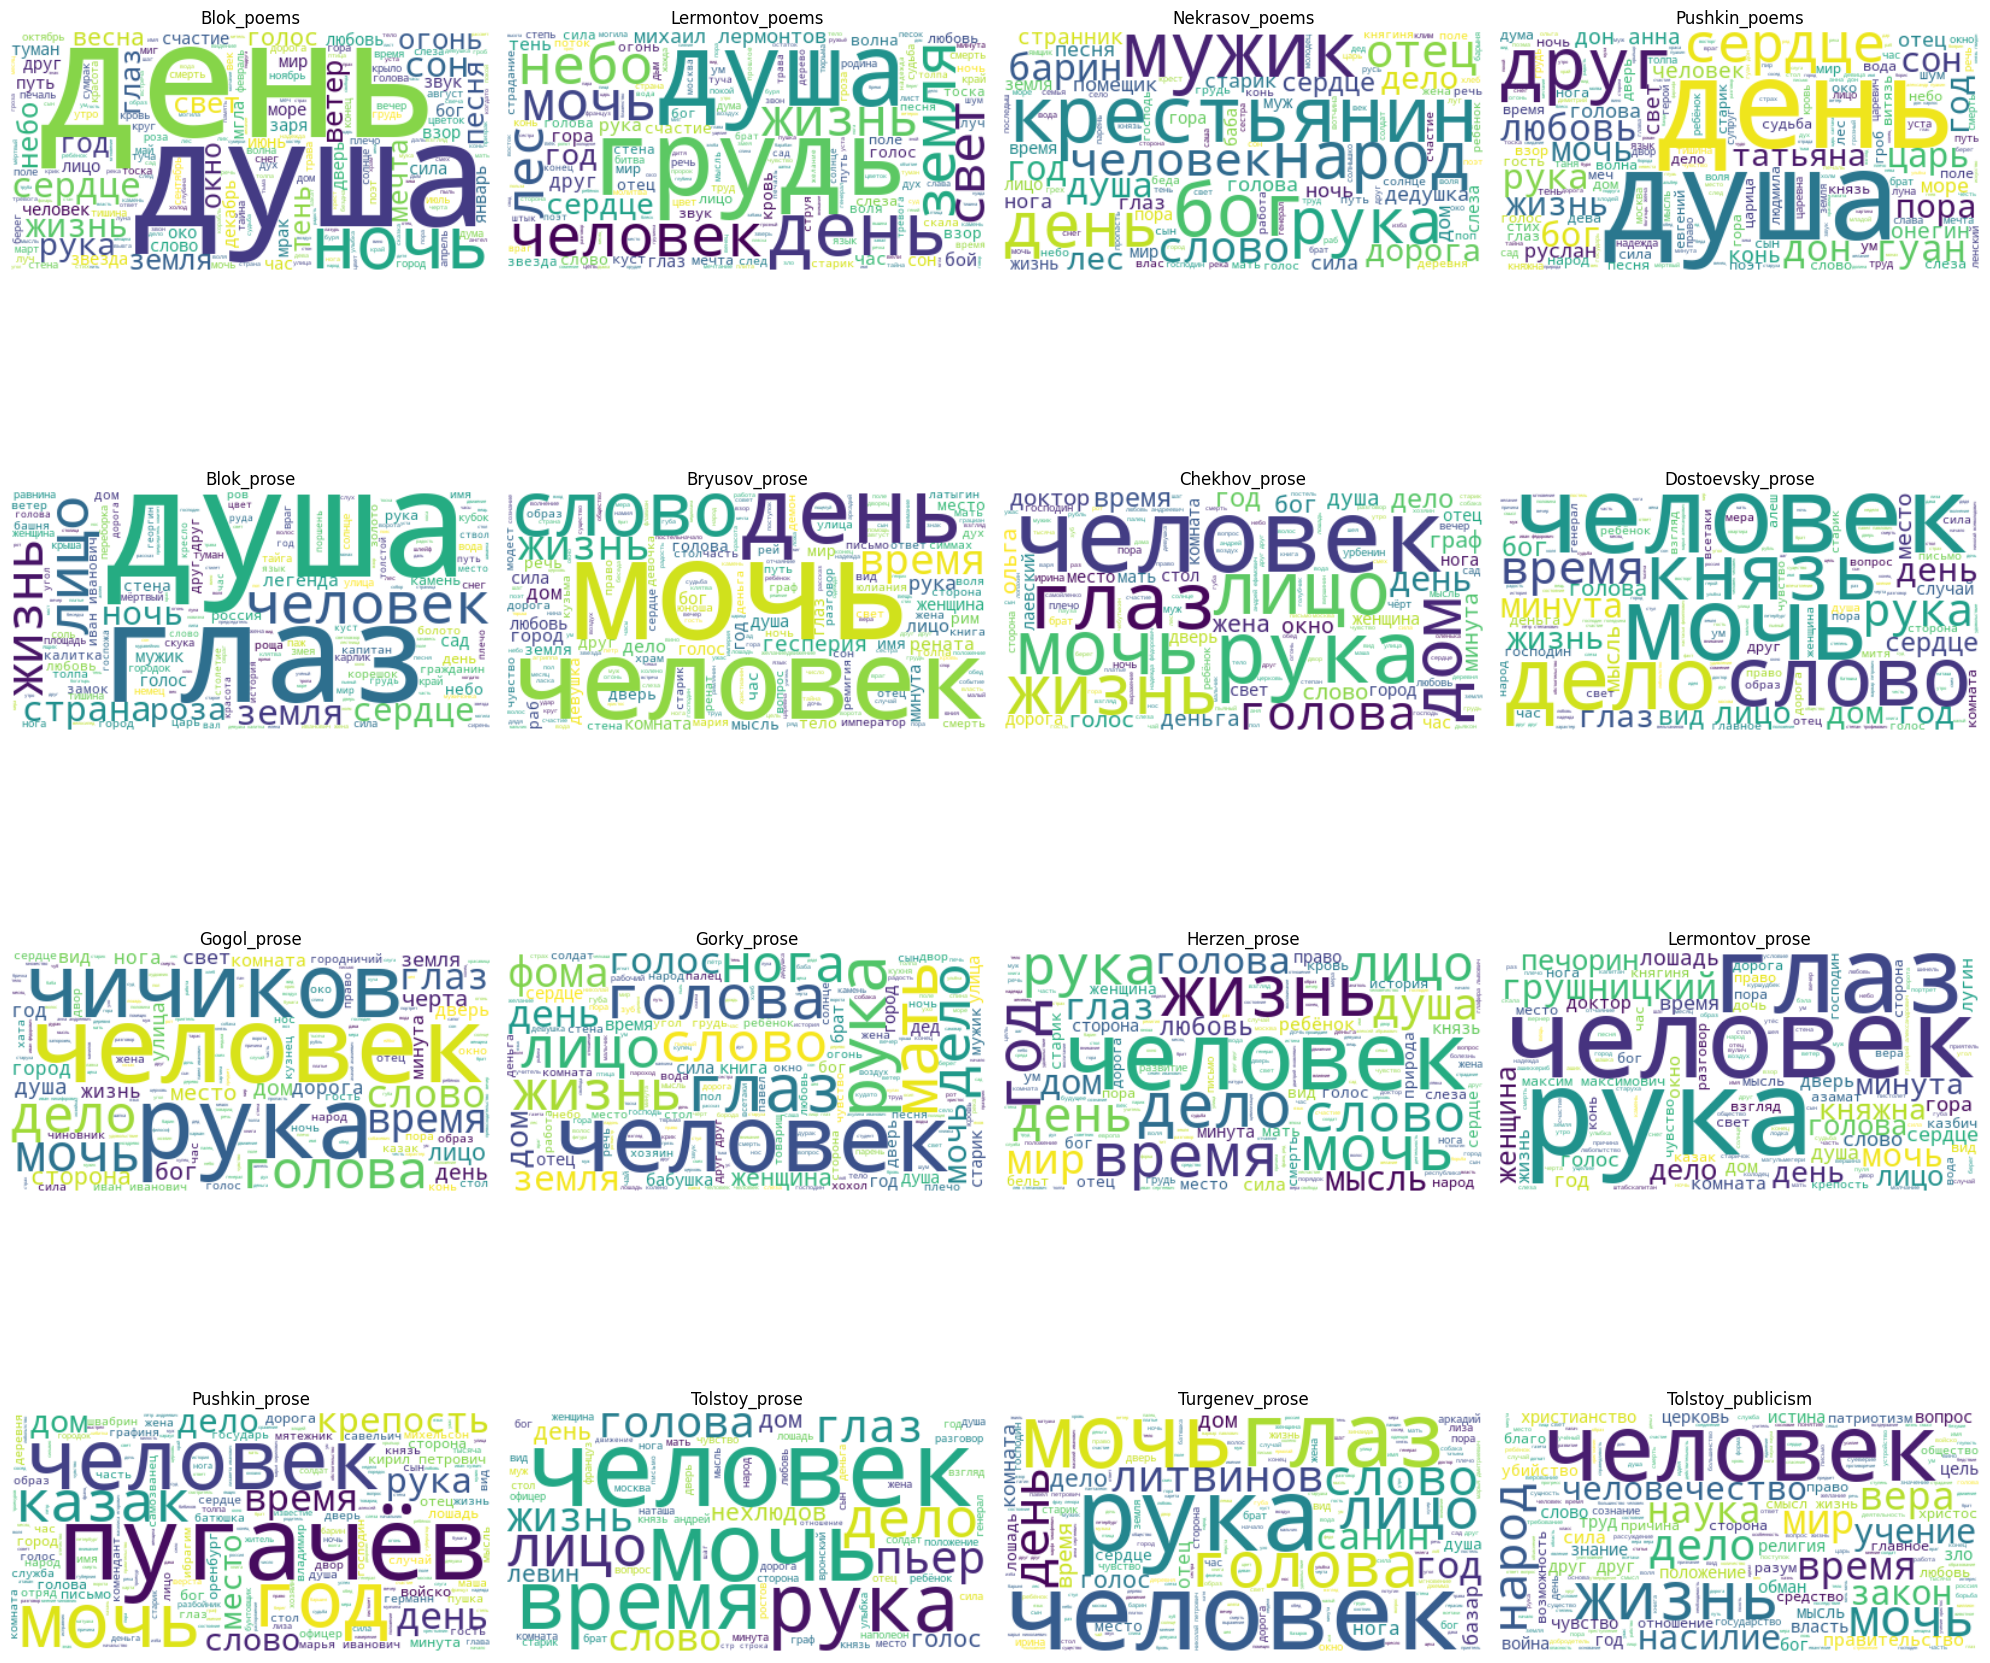

In [62]:
names = list(corpus_nouns.keys())
n = len(names)
rows = (n + 3) // 4

fig, axes = plt.subplots(rows, 4, figsize=(20, rows * 5))
axes = axes.flatten()

for i, name in enumerate(names):
    text = corpus_nouns[name]['text']
    wordcloud = WordCloud(width=400, height=200, background_color='white').generate(text)
    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(name)

for i in range(n, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

Вероятно глагол "мочь" и существительное "мочь" парсером было распознано как существительное значительно чаще, чем есть на самом деле. Не будет делать на нем акцент.

# Выводы

Поэзия посвящена внутреннему миру: душа, день, ночь, сердце. Поэзия Некрасова отличается, она посвящена крестьянской жизни: мужик, крестьянин, народ, барин.

Проза Блока близка к его поэзии, центральная тема - душа. Центральная тема для прозы в целом - человек.

Публицистика Толстого посвящена жизни человека и вере.

# Тематическое моделирование LDA

Попробуем иной способ для поиска тем в творчестве авторов.

Удалим имена собственные, они зашумляют темы.

In [78]:
corpus_no_names = {}

for name, data in corpus_nouns.items():
    tokens = data['tokens']
    tokens_filtered = []
    
    for word in tokens:
        parsed = morph.parse(word)[0]
        if 'Name' not in parsed.tag:
            tokens_filtered.append(word)
    
    corpus_no_names[name] = {
        'author': data['author'],
        'genre': data['genre'],
        'text': ' '.join(tokens_filtered),
        'tokens': tokens_filtered,
        'file_count': data['file_count'],
        'year_start': data['year_start'],
        'year_end': data['year_end']
    }

Создаем матрицы документ-термин.

In [79]:
texts = [data['text'] for data in corpus_nouns.values()]
names = list(corpus_nouns.keys())

vectorizer = CountVectorizer(max_features=1000, max_df=0.9, min_df=5)
dtm = vectorizer.fit_transform(texts)

Обучаем модель, оставляем стандартные параметры, кроме количества тем.

In [80]:
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(dtm)

,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",5
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'batch'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",10
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


In [81]:
feature_names = vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(lda.components_):
    top_words_idx = topic.argsort()[:-11:-1]
    top_words = [feature_names[i] for i in top_words_idx]
    print(f"Тема {topic_idx + 1}: {', '.join(top_words)}")

Тема 1: комната, император, мария, рим, письмо, дон, граф, вопрос, муж, храм
Тема 2: иванович, иван, пугачёв, казак, комната, петрович, вера, вопрос, крепость, положение
Тема 3: князь, пьер, лошадь, андрей, наташа, комната, граф, марья, анна, княжна
Тема 4: князь, иванович, комната, павлович, алеш, иван, петрович, вопрос, письмо, всетаки
Тема 5: фома, комната, бабушка, дед, павел, палец, хозяин, господь, солдат, ирина


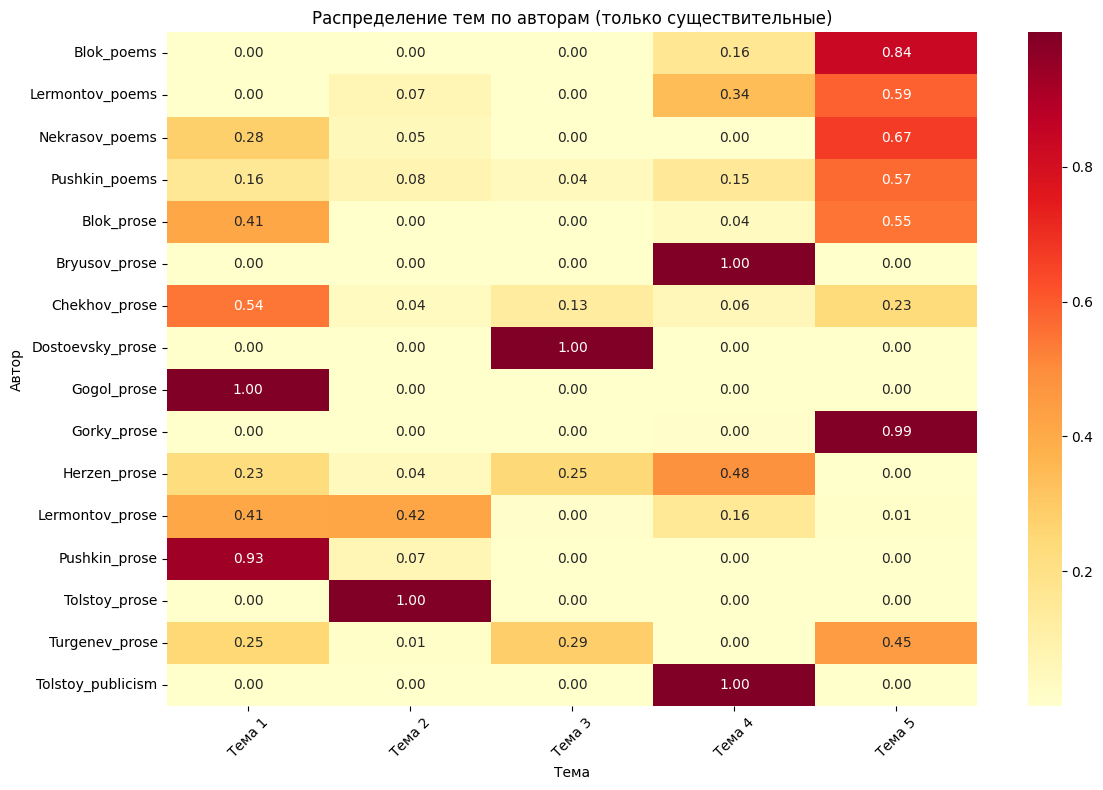

In [74]:
topic_distribution = lda.transform(dtm)

topic_df = pd.DataFrame(topic_distribution, columns=[f"Тема {i+1}" for i in range(5)], index=names)

plt.figure(figsize=(12, 8))
sns.heatmap(topic_df, annot=True, fmt='.2f', cmap='YlOrRd')
plt.title('Распределение тем по авторам (только существительные)')
plt.xlabel('Тема')
plt.ylabel('Автор')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

LDA анализ не смог выделить значимых тем. Проблемы возникли потому что: слишком маленький корпус, LDA не различает жанры, подкорпусы по авторам слишком разные по объему.

# Анализ близости авторов

Посмотрим насколько авторы близки друг к другу.

In [83]:
texts = [data['text'] for data in corpus_nouns.values()]
names = list(corpus_nouns.keys())

vectorizer = TfidfVectorizer(max_features=500)
tfidf = vectorizer.fit_transform(texts)

In [84]:
similarity = cosine_similarity(tfidf)
distance = 1 - similarity

In [88]:
similarity_df = pd.DataFrame(similarity, index=names, columns=names)
print(similarity_df.round(2))

                   Blok_poems  Lermontov_poems  Nekrasov_poems  Pushkin_poems  \
Blok_poems               1.00             0.81            0.63           0.77   
Lermontov_poems          0.81             1.00            0.64           0.76   
Nekrasov_poems           0.63             0.64            1.00           0.69   
Pushkin_poems            0.77             0.76            0.69           1.00   
Blok_prose               0.73             0.67            0.58           0.62   
Bryusov_prose            0.52             0.54            0.51           0.55   
Chekhov_prose            0.60             0.62            0.67           0.65   
Dostoevsky_prose         0.49             0.54            0.58           0.63   
Gogol_prose              0.50             0.52            0.59           0.57   
Gorky_prose              0.57             0.61            0.66           0.59   
Herzen_prose             0.58             0.65            0.65           0.66   
Lermontov_prose          0.6

Дендрограмма

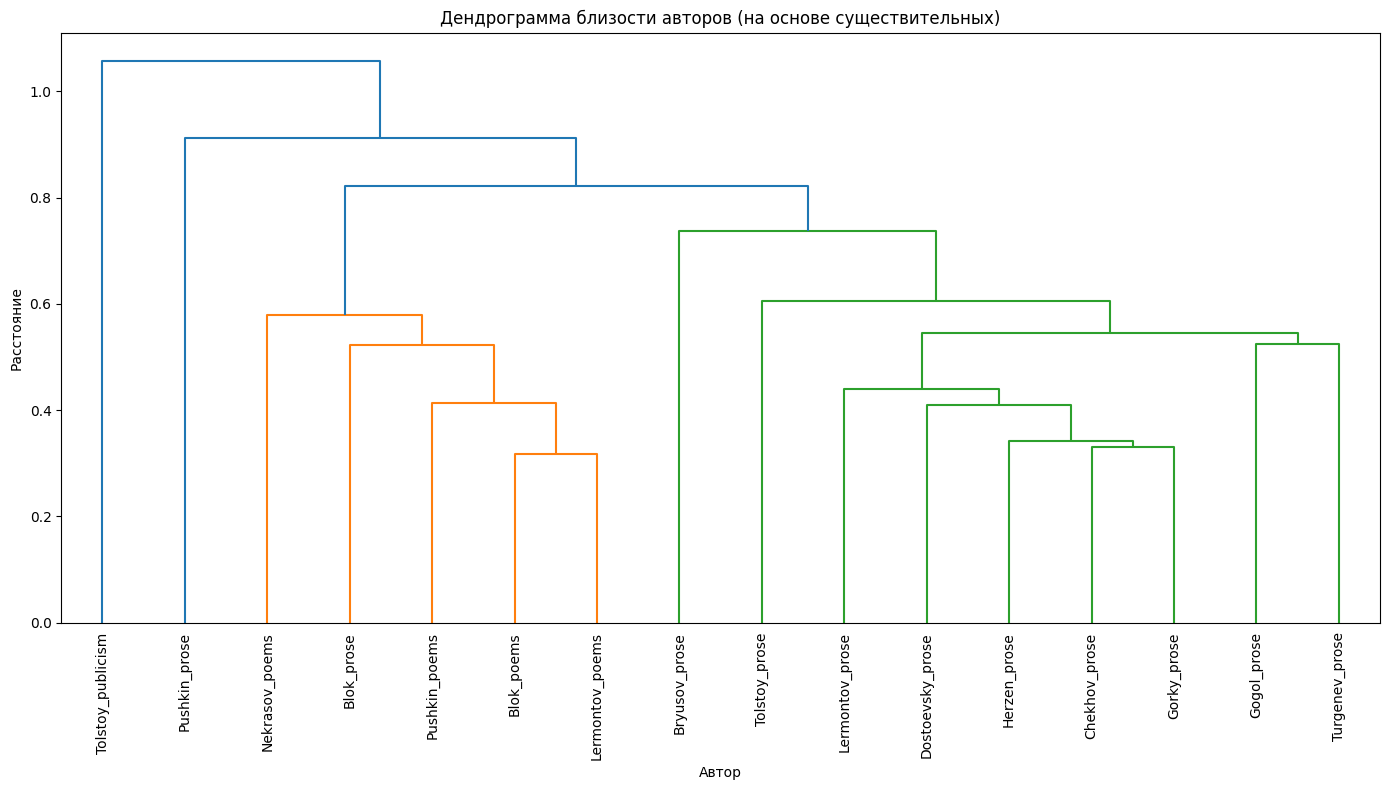

In [87]:
linkage = sch.linkage(distance, method='average')

plt.figure(figsize=(14, 8))
sch.dendrogram(linkage, labels=names, leaf_rotation=90, leaf_font_size=10)
plt.title('Дендрограмма близости авторов (на основе существительных)')
plt.xlabel('Автор')
plt.ylabel('Расстояние')
plt.tight_layout()
plt.show()

Тепловая карта близости

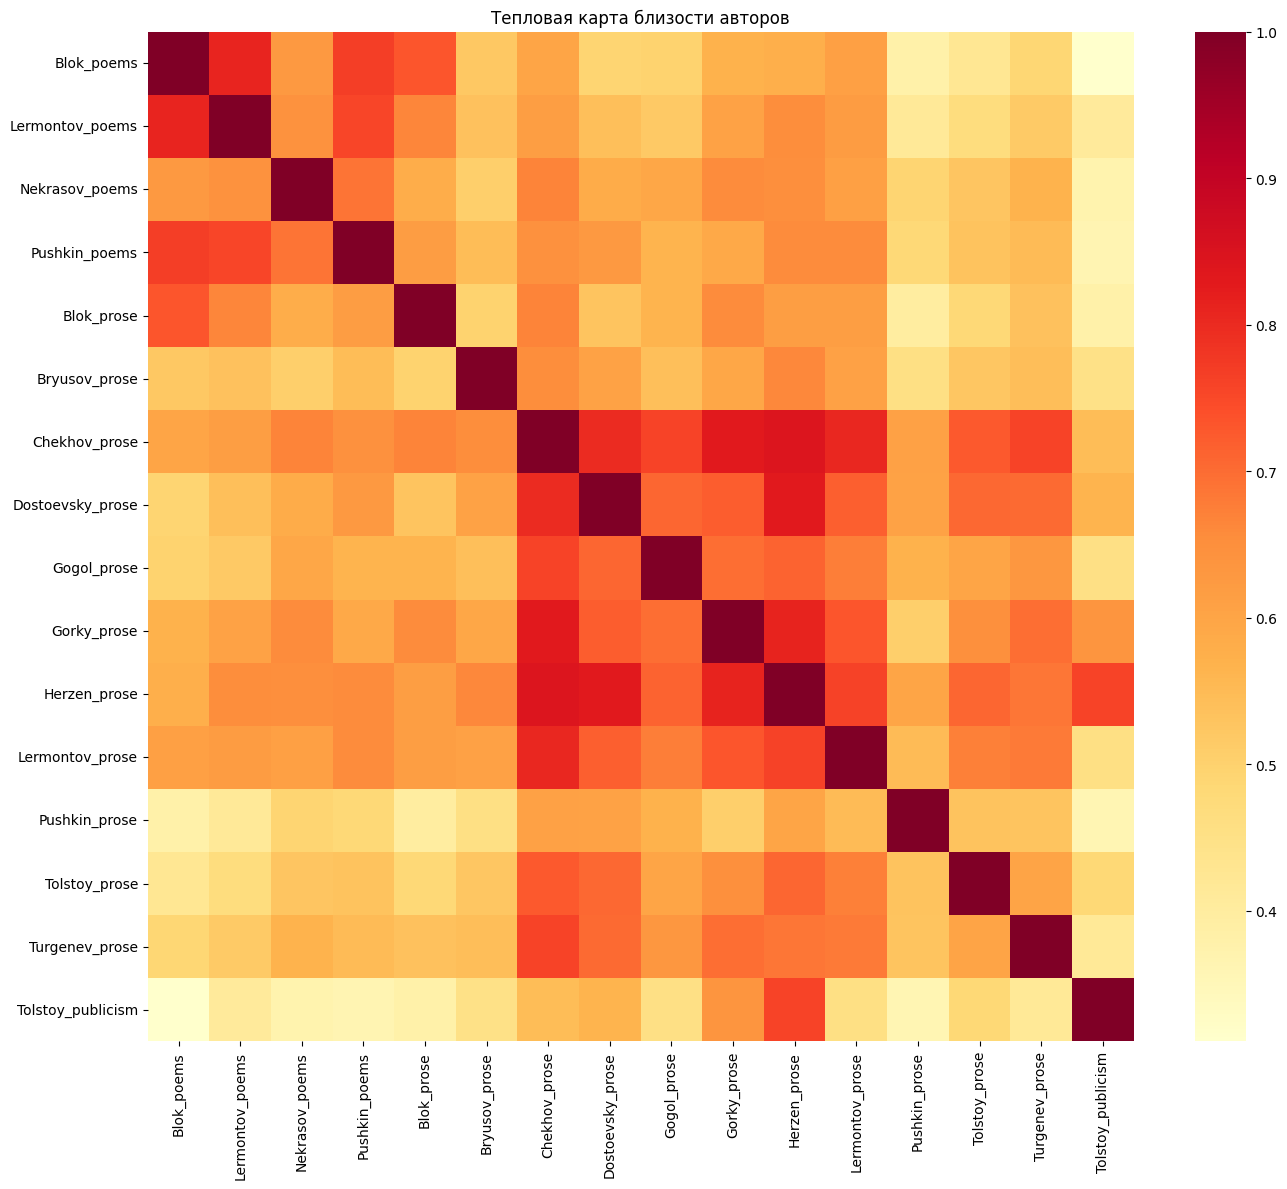

In [90]:
plt.figure(figsize=(14, 12))
sns.heatmap(similarity_df, annot=False, cmap='YlOrRd', xticklabels=True, yticklabels=True)
plt.title('Тепловая карта близости авторов')
plt.tight_layout()
plt.show()

# Выводы

Проза Пушкина ближе к поэзии, чем к остальной прозе. Публицистика Толстого стоит отдельно, что объясняется уникальностью жанра.

# Лексическое разнообразие

In [91]:
ttr_results = []

for name, data in corpus_cleaned.items():
    tokens = data['tokens']
    unique_tokens = set(tokens)
    ttr = len(unique_tokens) / len(tokens) if tokens else 0
    ttr_results.append({'author': name, 'ttr': ttr, 'total_words': len(tokens), 'unique_words': len(unique_tokens)})

ttr_df = pd.DataFrame(ttr_results).sort_values('ttr', ascending=False)

print("Лексическое разнообразие (TTR):")
print(ttr_df.round(4))

Лексическое разнообразие (TTR):
               author     ttr  total_words  unique_words
4          Blok_prose  0.5614         3821          2145
1     Lermontov_poems  0.4850         4235          2054
2      Nekrasov_poems  0.2711        34474          9347
11    Lermontov_prose  0.2309        27099          6257
3       Pushkin_poems  0.1979        51246         10140
12      Pushkin_prose  0.1550        87509         13567
10       Herzen_prose  0.1527       111518         17031
0          Blok_poems  0.1476        72920         10760
15  Tolstoy_publicism  0.1452        55454          8051
6       Chekhov_prose  0.1057       166919         17644
14     Turgenev_prose  0.1044       209555         21872
8         Gogol_prose  0.1038       205045         21282
5       Bryusov_prose  0.0865       246948         21352
9         Gorky_prose  0.0676       404177         27321
13      Tolstoy_prose  0.0496       823222         40870
7    Dostoevsky_prose  0.0426       914841         38985

# Выводы

Поэзия лексически разнообразнее прозы. Блок - исключение: его проза по разнообразию превосходит даже стихи. Тексты Достоевского и Толстого предсказуемо менее разнообразны из-за объемов произведений.

# Анализ уникальных слов

In [92]:
texts = [data['text'] for data in corpus_cleaned.values()]
names = list(corpus_cleaned.keys())

vectorizer = TfidfVectorizer(max_features=500)
tfidf = vectorizer.fit_transform(texts)
feature_names = vectorizer.get_feature_names_out()

print("\nТоп-10 уникальных слов для каждого автора:")
print("-" * 60)

for i, name in enumerate(names):
    tfidf_row = tfidf[i].toarray()[0]
    top_indices = tfidf_row.argsort()[-11:-1][::-1]
    top_words = [feature_names[idx] for idx in top_indices]
    print(f"{name}: {', '.join(top_words)}")


Топ-10 уникальных слов для каждого автора:
------------------------------------------------------------
Blok_poems: ночь, душа, сердце, сон, жизнь, рука, идти, знать, огонь, небо
Lermontov_poems: душа, день, земля, человек, знать, небо, мочь, стать, один, лес
Nekrasov_poems: идти, мужик, тот, бог, знать, народ, барин, стать, рука, день
Pushkin_poems: день, душа, видеть, знать, один, сердце, князь, любовь, сказать, анна
Blok_prose: глаз, друг, стать, лицо, человек, знать, русский, тот, жизнь, самый
Bryusov_prose: говорить, день, мочь, человек, тот, один, слово, знать, стать, жизнь
Chekhov_prose: говорить, человек, знать, один, рука, глаз, лицо, стать, такой, идти
Dostoevsky_prose: говорить, человек, сказать, один, такой, сам, мочь, князь, хотеть, дело
Gogol_prose: такой, говорить, человек, один, рука, знать, голова, иван, дело, иванович
Gorky_prose: говорить, сказать, рука, глаз, мать, знать, голова, лицо, фома, жизнь
Herzen_prose: знать, жизнь, сказать, говорить, один, год, дело, мочь

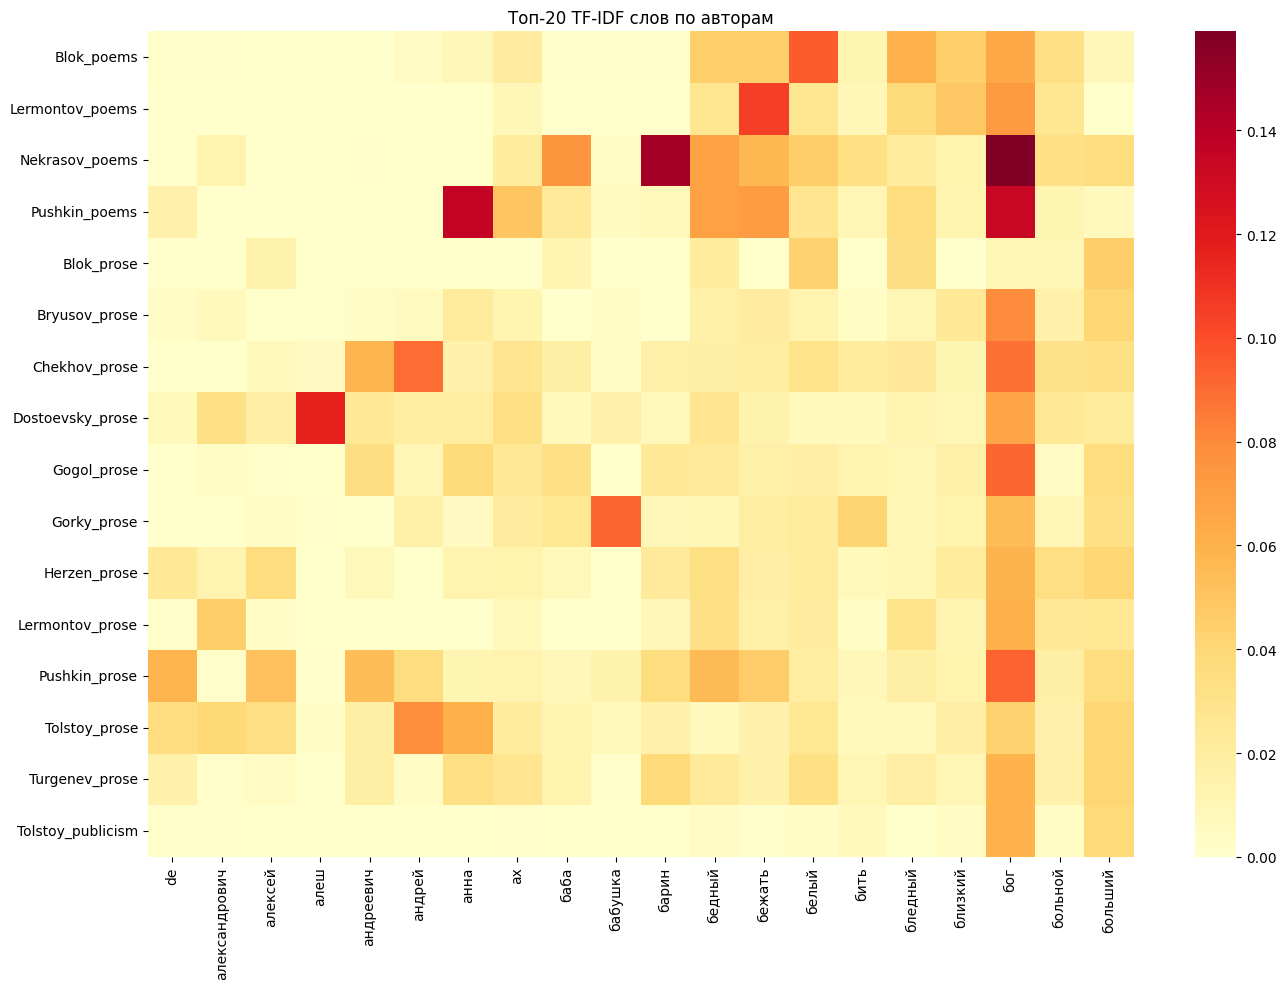

In [93]:
unique_words_df = pd.DataFrame(tfidf.toarray(), columns=feature_names, index=names)

plt.figure(figsize=(14, 10))
sns.heatmap(unique_words_df.iloc[:, :20], cmap='YlOrRd', xticklabels=True, yticklabels=True)
plt.title('Топ-20 TF-IDF слов по авторам')
plt.tight_layout()
plt.show()

# Выводы

Неожиданно у Толстого в лидируют имена собственные. Это значит, что его проза сильнее других завязана на конкретных героях.

Проза едина по базовой лексике.

Поэзия также едина, сильно выделяется только Некрасов.

# Анализ частей речи

Считаем части речи для каждого автора.

In [109]:
pos_stats = defaultdict(lambda: defaultdict(int))

for name, data in corpus_cleaned.items():
    for word in data['tokens']:
        parsed = morph.parse(word)[0]
        pos = parsed.tag.POS
        if pos:
            pos_stats[name][pos] += 1

Создаем таблицу с долями.

In [115]:
pos_df = pd.DataFrame(pos_stats).fillna(0).T

pos_df['total'] = pos_df.sum(axis=1)
for col in pos_df.columns:
    if col != 'total':
        pos_df[col] = pos_df[col] / pos_df['total']

pos_df = pos_df.drop('total', axis=1)

Фильтруем

In [116]:
pos_df = pos_df[[col for col in ['NOUN', 'VERB', 'INFN', 'ADJF', 'ADJS', 'ADVB', 'NPRO', 'PRED', 'PREP', 'CONJ', 'PRCL', 'INTJ', 'NUMR'] if col in pos_df.columns]]

Визуализируем

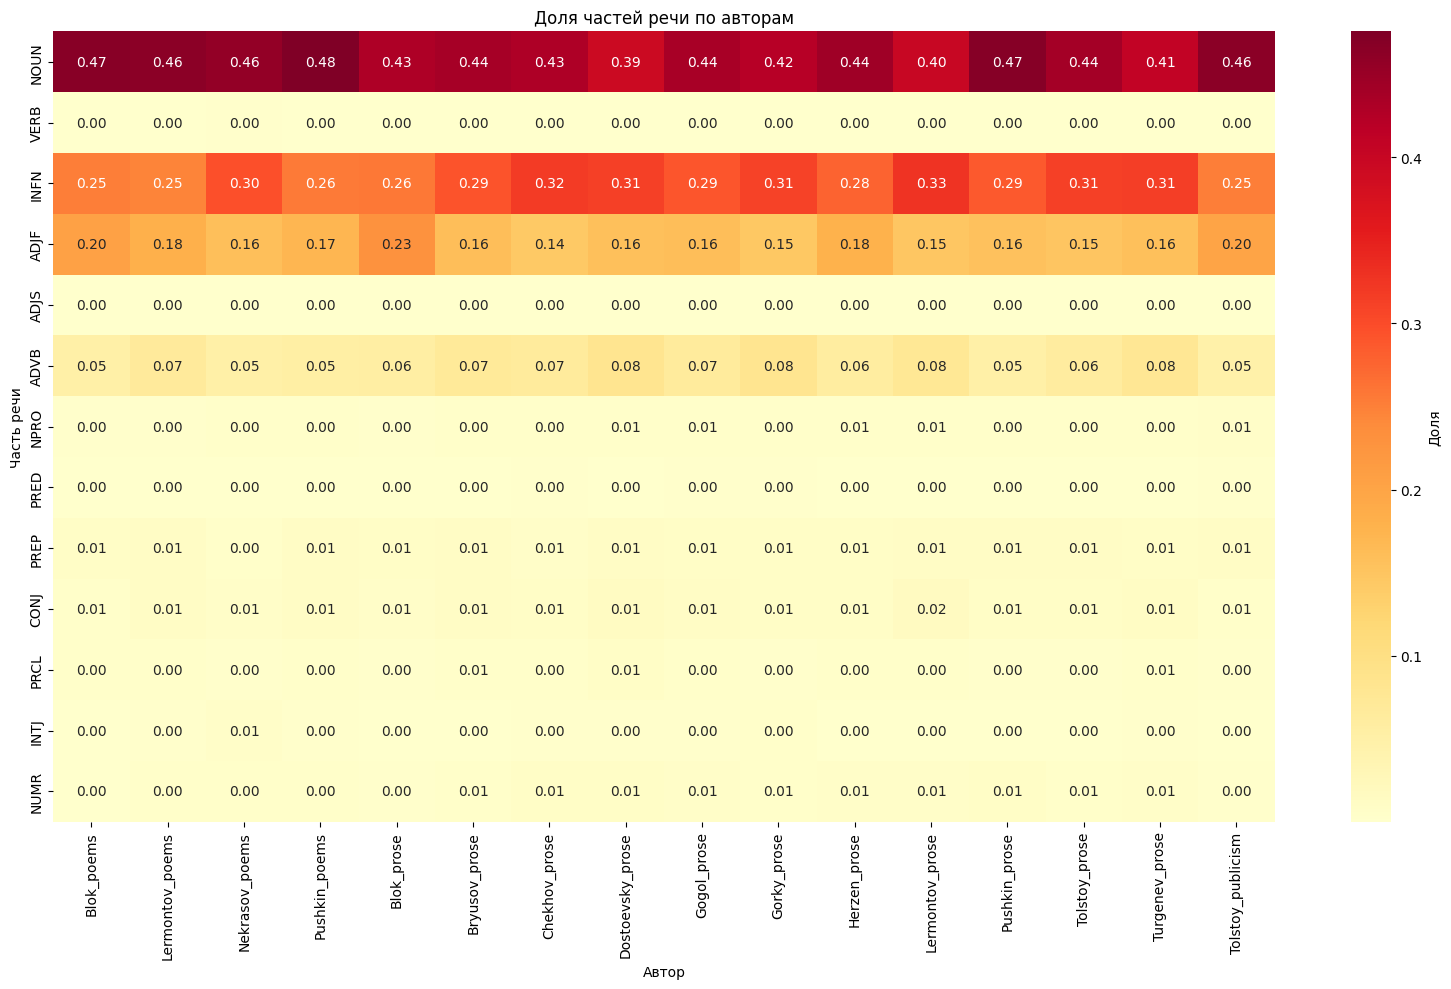

In [117]:
plt.figure(figsize=(16, 10))
sns.heatmap(pos_df.T, annot=True, fmt='.2f', cmap='YlOrRd', cbar_kws={'label': 'Доля'})
plt.title('Доля частей речи по авторам')
plt.xlabel('Автор')
plt.ylabel('Часть речи')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [118]:
print("Доля частей речи по авторам:\n")
print(pos_df.round(3))

Доля частей речи по авторам:

                    NOUN   VERB   INFN   ADJF   ADJS   ADVB   NPRO   PRED  \
Blok_poems         0.467  0.001  0.252  0.205  0.000  0.050  0.003  0.001   
Lermontov_poems    0.464  0.001  0.246  0.182  0.000  0.068  0.003  0.001   
Nekrasov_poems     0.457  0.002  0.297  0.158  0.001  0.052  0.004  0.002   
Pushkin_poems      0.476  0.001  0.256  0.172  0.001  0.054  0.005  0.001   
Blok_prose         0.431  0.001  0.257  0.230  0.000  0.056  0.003  0.000   
Bryusov_prose      0.437  0.001  0.293  0.161  0.000  0.069  0.005  0.001   
Chekhov_prose      0.430  0.001  0.320  0.143  0.001  0.067  0.004  0.002   
Dostoevsky_prose   0.393  0.001  0.313  0.157  0.001  0.083  0.006  0.002   
Gogol_prose        0.437  0.001  0.291  0.160  0.000  0.066  0.005  0.003   
Gorky_prose        0.420  0.001  0.312  0.146  0.000  0.084  0.004  0.002   
Herzen_prose       0.445  0.001  0.277  0.179  0.001  0.060  0.006  0.002   
Lermontov_prose    0.400  0.001  0.328  0.148 

# Выводы

Существительных в каждом тексте больше всего. Немного меньше у Достоевского.

Глаголы чаще всего в прозе Лермонтова и Достоевского.

Прилагательных больше всего в прозе Блока.

Наречия немного чаще встречаются у Достоевского, Тургенева, Горького и прозы Лермонтова.

# Анализ динамики топ 10 существительных по годам

Находим топ 10 слов для всех авторов.

In [124]:
all_nouns = []

for name, data in corpus_nouns.items():
    all_nouns.extend(data['tokens'])

noun_freq = Counter(all_nouns)

selected_nouns = [word for word, count in noun_freq.most_common(10)]

print("Топ-10 существительных по всем авторам:")
for i, word in enumerate(selected_nouns, 1):
    print(f"{i}. {word} ({noun_freq[word]} упоминаний)")

Топ-10 существительных по всем авторам:
1. человек (23193 упоминаний)
2. мочь (14161 упоминаний)
3. рука (13708 упоминаний)
4. глаз (10434 упоминаний)
5. лицо (10419 упоминаний)
6. дело (10404 упоминаний)
7. слово (9562 упоминаний)
8. жизнь (9434 упоминаний)
9. время (9243 упоминаний)
10. день (9045 упоминаний)


Уберем отсюда "мочь". Оно вероятно было неверно распознано как существительное.

In [125]:
all_nouns = []

for name, data in corpus_nouns.items():
    all_nouns.extend(data['tokens'])

noun_freq = Counter(all_nouns)

if 'мочь' in noun_freq:
    del noun_freq['мочь']

selected_nouns = [word for word, count in noun_freq.most_common(10)]

print("Топ-10 существительных по всем авторам:")
for i, word in enumerate(selected_nouns, 1):
    print(f"{i}. {word} ({noun_freq[word]} упоминаций)")

Топ-10 существительных по всем авторам:
1. человек (23193 упоминаций)
2. рука (13708 упоминаций)
3. глаз (10434 упоминаций)
4. лицо (10419 упоминаций)
5. дело (10404 упоминаций)
6. слово (9562 упоминаций)
7. жизнь (9434 упоминаций)
8. время (9243 упоминаций)
9. день (9045 упоминаций)
10. голова (8294 упоминаций)


Визуализируем

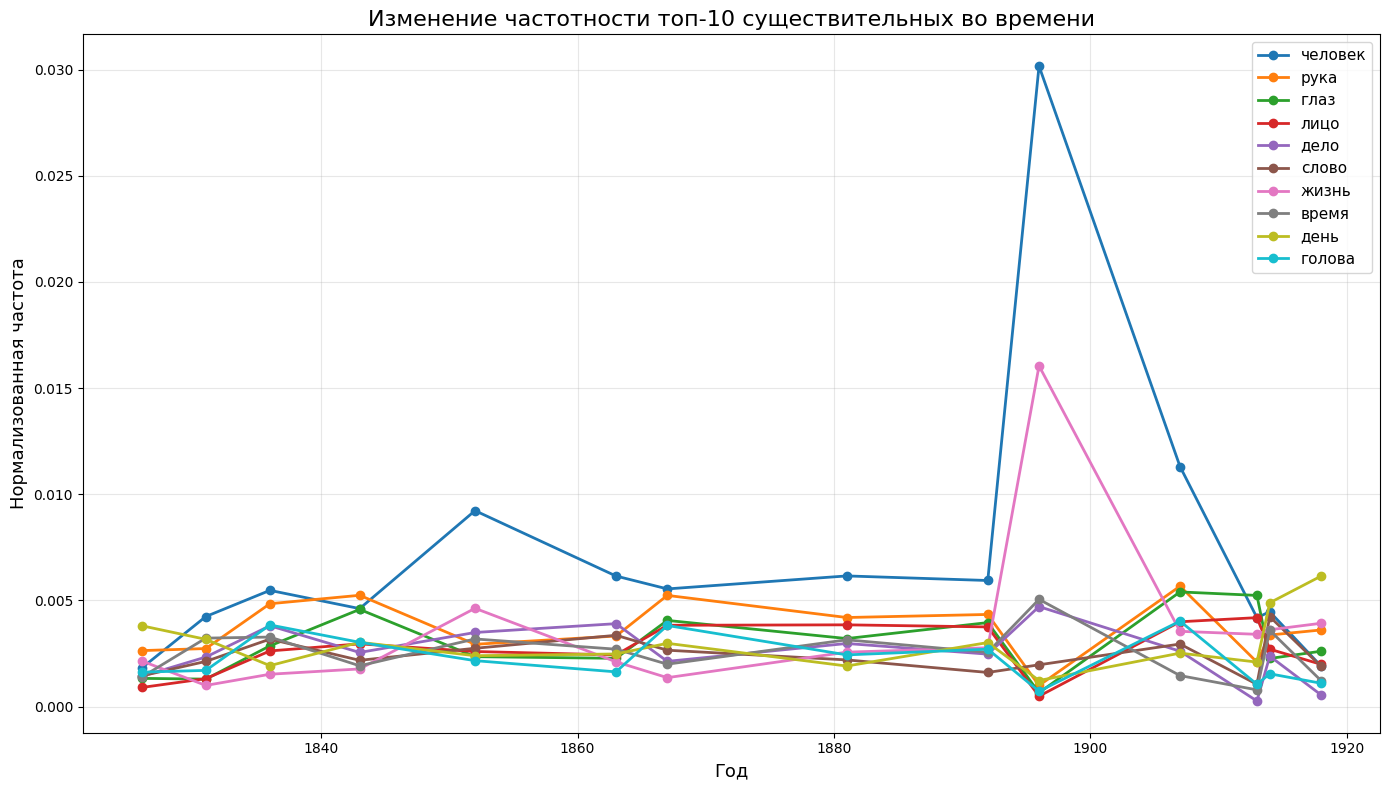

In [128]:
word_freq_by_year = defaultdict(lambda: defaultdict(int))
word_count_by_year = defaultdict(int)

for name, data in corpus_cleaned.items():
    if not data['year_start'] or not data['year_end']:
        continue
    
    avg_year = (data['year_start'] + data['year_end']) // 2
    
    for word in data['tokens']:
        word_freq_by_year[word][avg_year] += 1
        word_count_by_year[avg_year] += 1

word_freq_norm = defaultdict(dict)

for word, years in word_freq_by_year.items():
    for year, freq in years.items():
        word_freq_norm[word][year] = freq / word_count_by_year[year]

plt.figure(figsize=(14, 8))

for word in selected_nouns:
    if word in word_freq_norm:
        years = sorted(word_freq_norm[word].keys())
        freqs = [word_freq_norm[word][year] for year in years]
        plt.plot(years, freqs, marker='o', linewidth=2, markersize=6, label=word)

plt.title('Изменение частотности топ-10 существительных во времени', fontsize=16)
plt.xlabel('Год', fontsize=13)
plt.ylabel('Нормализованная частота', fontsize=13)
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Мало информативности. Вероятный всплеск для в конце XIX века связан с большим количеством произведений этого периода в датасете.

# Корреляция длины предложения и года

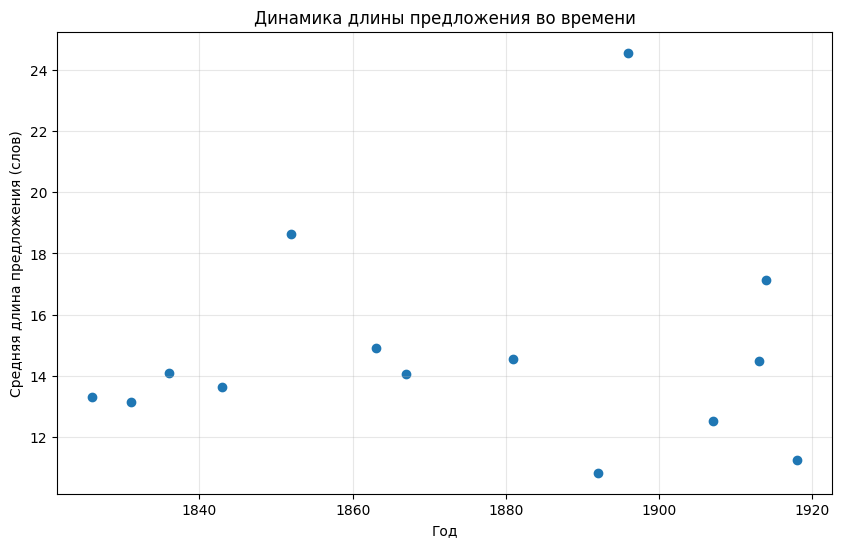

In [130]:
def avg_sentence_len_from_original(name):
    data = corpora[name]
    text = data['text']
    
    sentences = re.split(r'[.!?]+', text)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 10]
    
    if not sentences:
        return 0
    
    lens = [len(s.split()) for s in sentences]
    return sum(lens) / len(lens)

years = []
lengths = []

for name, data in corpus_cleaned.items():
    if data['year_start'] and data['year_end']:
        avg_year = (data['year_start'] + data['year_end']) // 2
        years.append(avg_year)
        lengths.append(avg_sentence_len_from_original(name))

plt.figure(figsize=(10, 6))
plt.scatter(years, lengths)
plt.xlabel('Год')
plt.ylabel('Средняя длина предложения (слов)')
plt.title('Динамика длины предложения во времени')
plt.grid(True, alpha=0.3)
plt.show()

Посмотрим на тексты, которые были написаны в годы, показывающие экстремальные значения.

In [133]:
for name, data in corpus_cleaned.items():
    if data['year_start'] and data['year_end']:
        avg_year = (data['year_start'] + data['year_end']) // 2
        sentence_len = avg_sentence_len_from_original(name)
        print(f"{name}: {sentence_len:.1f} слов, год ~{avg_year}")

Blok_poems: 11.2 слов, год ~1918
Pushkin_poems: 13.3 слов, год ~1826
Blok_prose: 14.5 слов, год ~1913
Bryusov_prose: 17.1 слов, год ~1914
Chekhov_prose: 10.8 слов, год ~1892
Dostoevsky_prose: 14.9 слов, год ~1863
Gogol_prose: 14.1 слов, год ~1836
Gorky_prose: 12.5 слов, год ~1907
Herzen_prose: 18.6 слов, год ~1852
Lermontov_prose: 13.6 слов, год ~1843
Pushkin_prose: 13.1 слов, год ~1831
Tolstoy_prose: 14.5 слов, год ~1881
Turgenev_prose: 14.1 слов, год ~1867
Tolstoy_publicism: 24.6 слов, год ~1896


# Выводы

Самое высокое значение на графике объясняется публицистикой Толстого, которая, как мы уже знаем имеет максимальную среднюю длину предложения в выборке.

Топ 2 значение объясняется прозой Герцена.

# Анализ эмоциональной окраски

Точечно определим к какой тематике тяготеет автор.

In [136]:
positive_words = ['жизнь', 'любовь', 'друг', 'счастье', 'радость', 'свет', 'добро']
negative_words = ['смерть', 'боль', 'страх', 'горе', 'слеза', 'ужас', 'тьма']

sentiment_ratio = {}

for name, data in corpus_cleaned.items():
    tokens = data['tokens']
    pos_count = sum(1 for word in tokens if word in positive_words)
    neg_count = sum(1 for word in tokens if word in negative_words)
    ratio = pos_count / (neg_count + 1)
    sentiment_ratio[name] = ratio

for name, ratio in sorted(sentiment_ratio.items(), key=lambda x: -x[1]):
    print(f"{name}: {ratio:.2f}")

Tolstoy_publicism: 13.33
Blok_prose: 11.25
Bryusov_prose: 3.44
Lermontov_poems: 3.11
Gogol_prose: 3.08
Pushkin_poems: 2.95
Gorky_prose: 2.94
Herzen_prose: 2.92
Tolstoy_prose: 2.90
Dostoevsky_prose: 2.82
Chekhov_prose: 2.72
Turgenev_prose: 2.69
Blok_poems: 2.64
Lermontov_prose: 2.61
Pushkin_prose: 2.04
Nekrasov_poems: 1.83


# Выводы

Самые позитивные - публицист Толстой и Блок прозаик, что интересно Толстой немного позитивнее Блока.

Самый негативный - Некрасов, что интересно сочетается с его уникальностью в плане тематики. Некрасов писал о негативных сторонах крестьянской жизни.

# Облака слов для всего текста

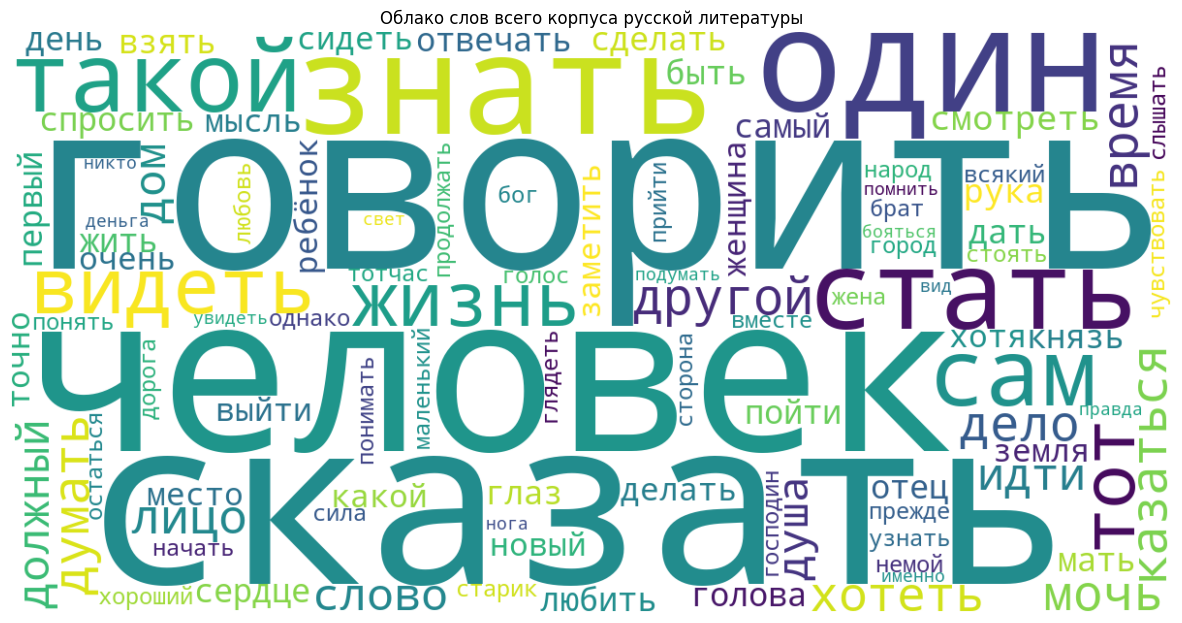

In [137]:
all_text = ' '.join([data['text'] for data in corpus_cleaned.values()])

wordcloud = WordCloud(width=1200, height=600, background_color='white', max_words=100).generate(all_text)

plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Облако слов всего корпуса русской литературы')
plt.show()

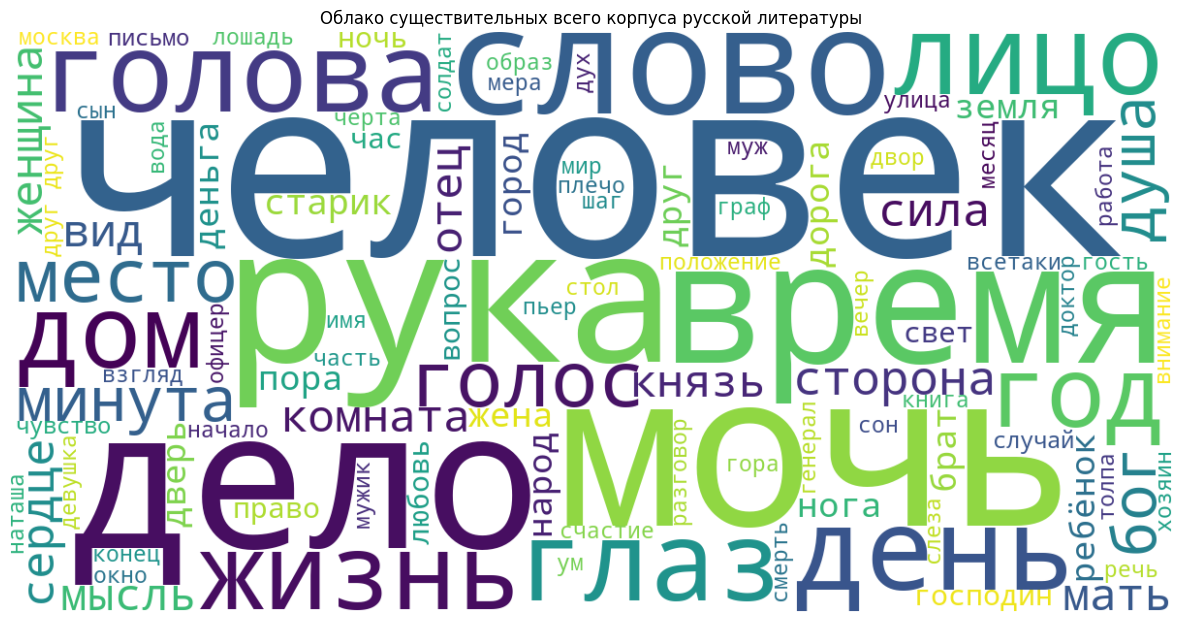

In [138]:
all_nouns_text = ' '.join([data['text'] for data in corpus_nouns.values()])

wordcloud = WordCloud(width=1200, height=600, background_color='white', max_words=100).generate(all_nouns_text)

plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Облако существительных всего корпуса русской литературы')
plt.show()

# Выводы

Центральные глаголы - глаголы речи: говорить, сказать. Центральная тема для всего датасета - человек.

# Машинное обучение для анализа текстов

# Предсказание жанра

Обучим random forest для автоматического определения поэзии или прозы. Для этого создадим отдельные подкорпуса с каждым произведением.

In [147]:
base_path = Path("RusLit-main")
file_data = []

encodings = ['utf-8', 'cp1251', 'koi8-r', 'iso-8859-5']

for genre_dir in base_path.iterdir():
    if not genre_dir.is_dir():
        continue
    
    genre = genre_dir.name
    
    for author_dir in genre_dir.iterdir():
        if not author_dir.is_dir():
            continue
        
        for file in author_dir.glob("*.txt"):
            for enc in encodings:
                try:
                    with open(file, 'r', encoding=enc) as f:
                        text = f.read()
                    file_data.append({
                        'author': author_dir.name,
                        'genre': genre,
                        'filename': file.name,
                        'text': text
                    })
                    break
                except UnicodeDecodeError:
                    continue

print(f"Собрано файлов: {len(file_data)}")
print(Counter([d['genre'] for d in file_data]))

Собрано файлов: 373
Counter({'prose': 269, 'poems': 78, 'publicism': 26})


На будущее сразу добавим информацию про годы.

In [160]:
for item in file_data:
    author_dir = base_path / item['genre'] / item['author']
    info_file = author_dir / "info.csv"
    
    if info_file.exists():
        with open(info_file, 'r', encoding='utf-8') as f:
            lines = f.readlines()
        
        for line in lines[1:]:
            line = line.strip()
            if not line:
                continue
            
            if '"' in line:
                parts = line.split('"')
                name = parts[1]
                year_part = parts[2].strip(',').strip()
            else:
                comma_index = line.find(',')
                name = line[:comma_index]
                year_part = line[comma_index + 1:]
            
            filename_without_ext = item['filename'].replace('.txt', '')
            
            if name == filename_without_ext:
                match = re.search(r'\d{4}', year_part)
                if match:
                    item['year'] = int(match.group())
                else:
                    item['year'] = None
                break
        else:
            item['year'] = None
    else:
        item['year'] = None

print(f"Файлов с годами: {len([item for item in file_data if item['year']])}")

Файлов с годами: 344


Очищаем новые корпуса.

In [161]:
russian_stopwords = stopwords.words('russian')

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    tokens = text.split()
    tokens = [word for word in tokens if word not in russian_stopwords and len(word) > 1]
    return ' '.join(tokens)

for item in file_data:
    item['clean_text'] = clean_text(item['text'])

Классифицируем жанры.

In [162]:
texts = [item['clean_text'] for item in file_data]
genres = [item['genre'] for item in file_data]

vectorizer = TfidfVectorizer(max_features=500)
X = vectorizer.fit_transform(texts)
y = genres

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       poems       1.00      0.88      0.93        16
       prose       0.93      1.00      0.96        54
   publicism       1.00      0.60      0.75         5

    accuracy                           0.95        75
   macro avg       0.98      0.83      0.88        75
weighted avg       0.95      0.95      0.94        75



# Выводы

Наша модель отлично распознает прозу и плохо распознает публицистику, из-за малого количества текстов.

# Предсказание авторов через XGBoost

In [163]:
texts = [item['clean_text'] for item in file_data]
authors = [item['author'] for item in file_data]

print(f"Всего файлов: {len(texts)}")
print(f"Уникальных авторов: {len(set(authors))}")
print(set(authors))

Всего файлов: 373
Уникальных авторов: 12
{'Gorky', 'Nekrasov', 'Gogol', 'Pushkin', 'Chekhov', 'Dostoevsky', 'Herzen', 'Lermontov', 'Tolstoy', 'Turgenev', 'Blok', 'Bryusov'}


In [164]:
encoder = LabelEncoder()
y = encoder.fit_transform(authors)

print("Соответствие авторов и чисел:")
for i, name in enumerate(encoder.classes_):
    print(f"{i}: {name}")

Соответствие авторов и чисел:
0: Blok
1: Bryusov
2: Chekhov
3: Dostoevsky
4: Gogol
5: Gorky
6: Herzen
7: Lermontov
8: Nekrasov
9: Pushkin
10: Tolstoy
11: Turgenev


Обучение модели.

In [165]:
vectorizer = TfidfVectorizer(max_features=500)
X = vectorizer.fit_transform(texts)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

Оценка качества.

In [166]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=encoder.classes_))

              precision    recall  f1-score   support

        Blok       1.00      0.33      0.50         3
     Bryusov       1.00      0.67      0.80         6
     Chekhov       0.79      1.00      0.88        15
  Dostoevsky       0.62      0.71      0.67         7
       Gogol       1.00      1.00      1.00         3
       Gorky       0.67      0.86      0.75         7
      Herzen       1.00      0.50      0.67         2
   Lermontov       0.50      0.25      0.33         4
    Nekrasov       1.00      1.00      1.00         3
     Pushkin       0.88      0.78      0.82         9
     Tolstoy       0.87      0.93      0.90        14
    Turgenev       1.00      1.00      1.00         2

    accuracy                           0.81        75
   macro avg       0.86      0.75      0.78        75
weighted avg       0.83      0.81      0.80        75



# Выводы

Модель хорошо предсказывает с авторами, у которых много произведений в выборке и проваливается на редких авторах. Для улучшения модели нужно увеличить количество произведений на таких авторов.

# Предсказание года написания

Предскажем год написания произведения с помощью линейной регрессии.

In [168]:
data_with_years = [item for item in file_data if item.get('year')]

texts = [item['clean_text'] for item in data_with_years]
years = [item['year'] for item in data_with_years]

print(f"Найдено файлов с годами: {len(texts)}")
print(f"Диапазон лет: {min(years)} - {max(years)}")

Найдено файлов с годами: 344
Диапазон лет: 1816 - 1934


Обучение модели.

In [170]:
vectorizer = TfidfVectorizer(max_features=500)
X = vectorizer.fit_transform(texts)
y = years

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Предсказание и оценка качества.

In [171]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Средняя абсолютная ошибка: {mae:.1f} лет")
print(f"R2 (доля объяснённой дисперсии): {r2:.3f}")

Средняя абсолютная ошибка: 18.2 лет
R2 (доля объяснённой дисперсии): 0.133


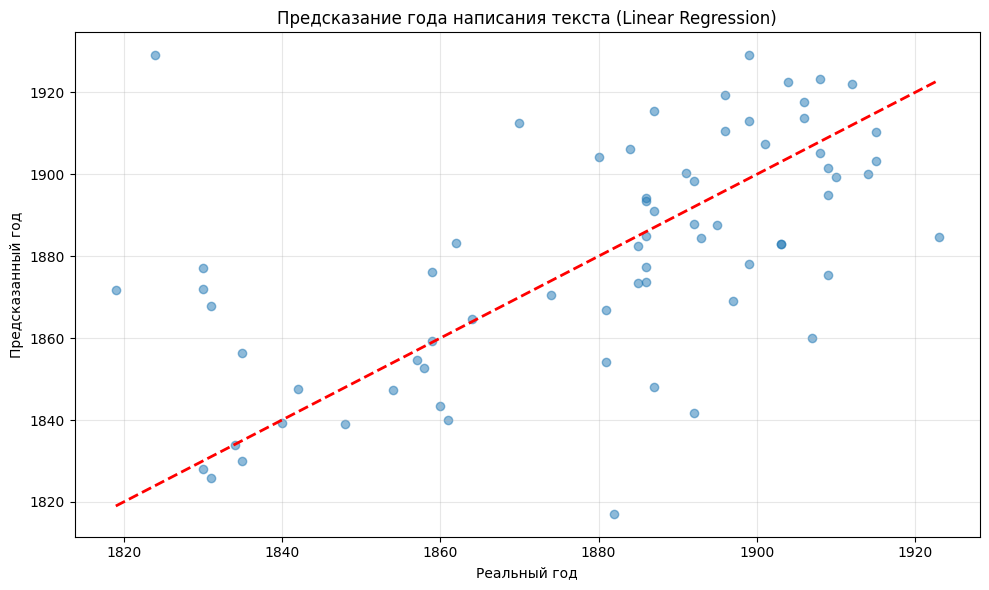

In [172]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', lw=2)
plt.xlabel('Реальный год')
plt.ylabel('Предсказанный год')
plt.title('Предсказание года написания текста (Linear Regression)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Выводы

Модель плохо предсказывает год. Модель почти не лучше, чем просто предсказывать средний год.

Попробуем нелинейную модель.

In [175]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"MAE: {mean_absolute_error(y_test, y_pred):.1f} лет")
print(f"R2: {r2_score(y_test, y_pred):.3f}")

MAE: 14.0 лет
R2: 0.564


# Выводы

Нелинейная модель сработала лучше. Причина: Random Forest умеет находить сложные зависимости.

Причины плохих результатов: мало данных, разброс годов внутри одно автора, например, Толстой писал на протяжении 60 лет.

# Интерпретация результатов

# Что сделано

1. Загружены 16 подкорпусов автор + жанр из репозитория русской литературы
2. Проведена очистка данных:
* приведение к нижнему регистру
* удаление пунктуации
* удаление стоп слов
* лемматизация
3. Выполнен анализ:
* количество слов в предложении
* частотность слов
* тематическое моделирование LDA
* анализ близости авторов
* лексическое разнообразие
* уникальные слов
* части речи
* динамика существительных по годам
* корреляция длины предложения и года
* эмоциональная окраска
4. Построены визуализации
* облака слов
* тепловые карты
* дендрограмма
* распределение тем
5. Рассмотрены:
* жанровые различия
* близость авторов
6. Применены модели машинного обучения
* Random forest
* XGBoost
* Линейная регрессия

# Что узнали

1. Поэзия и проза различаются по тематике и лексике.
2. Жанр играет главную роль в определении близости авторов. Прозаики ближе к прозаикам, поэты к поэтам.
3. Некрасов выделяется социально-крестьянской тематикой.
4. Публицистика Толстого стоит отдельно по всем метрикам.
5. Проза Блока лексически разнообразнее стихов
6. Лексическое разнообразие обратно пропорционально объему текстов. Как и ожидалось.
7. Проза и поэзия надежно различаются. Random forest хорошо их определяет, и плохо определяет публицистику, из-за малого количества текстов.
8. XGBoost модель хорошо хорошо определяет авторов. Для улучшения необходимо увеличивать количество текстов для авторов с маленьким количеством.
9. Линейная регрессия плохо предсказывает год написания текста, random forest делает это лучше. Существуют нелинейные зависимости.
10. Pymorphy3 вероятно неверно определяет часть речи для "мочь".

# Что можно улучшить

1. Увеличить количество публицистических текстов.
2. Увеличить количество данных для редких авторов или исключить их из анализа.
3. Добавить датировку всех произведений.
4. LDA не работает. Нужно удалять максимально имена персонажей, что затруднительно сделать автоматически, и увеличить объемы корпусов.
5. Увеличить выборку, добавить больше авторов, добавить авторов XVIII века, увеличить число авторов XX века.
6. Применить другие подходы. BERT, transformers вместо TF-IDF.